In [1]:
# === УСТАНОВКА ЗАВИСИМОСТЕЙ ===
!pip install faiss-cpu -q

import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

# --- Пути и артефакты ---
BASE_DIR = "homeworks/HW14"
ARTIFACTS_DIR = os.path.join(BASE_DIR, "artifacts")
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# --- Seed ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("✅ Imports and seed configured")
print("✅ FAISS installed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 59.9 MB/s eta 0:00:00
✅ Imports and seed configured
✅ FAISS installed successfully


In [2]:
# Создаём небольшую базу знаний (FAQ по Python)
# В реальном проекте можно загрузить из файлов

knowledge_base = [
    {
        "id": 1,
        "title": "Что такое Python?",
        "content": "Python — это высокоуровневый язык программирования общего назначения. Он был создан Гвидо ван Россумом и впервые выпущен в 1991 году. Python подчеркивает читаемость кода и позволяет разработчикам выражать концепции в меньшем количестве строк кода."
    },
    {
        "id": 2,
        "title": "Как установить Python?",
        "content": "Для установки Python посетите официальный сайт python.org и скачайте последнюю версию для вашей операционной системы. После загрузки запустите установщик и следуйте инструкциям. Рекомендуется добавить Python в PATH при установке на Windows."
    },
    {
        "id": 3,
        "title": "Что такое переменные в Python?",
        "content": "Переменные в Python используются для хранения данных. В отличие от других языков, Python не требует объявления типа переменной. Тип определяется автоматически на основе присвоенного значения. Пример: x = 5 создаёт переменную x целочисленного типа."
    },
    {
        "id": 4,
        "title": "Как работать со списками в Python?",
        "content": "Списки в Python — это упорядоченные изменяемые коллекции элементов. Создаются с помощью квадратных скобок: my_list = [1, 2, 3]. Основные операции: append() для добавления, remove() для удаления, len() для получения длины. Списки могут содержать элементы разных типов."
    },
    {
        "id": 5,
        "title": "Что такое функции в Python?",
        "content": "Функции в Python определяются с помощью ключевого слова def. Они позволяют организовать код в переиспользуемые блоки. Пример: def greet(name): return f'Hello, {name}'. Функции могут принимать аргументы и возвращать значения."
    },
    {
        "id": 6,
        "title": "Как обрабатывать исключения в Python?",
        "content": "Обработка исключений в Python осуществляется с помощью конструкций try, except, finally. Пример: try: result = 10/0 except ZeroDivisionError: print('Деление на ноль'). Это позволяет программе продолжать работу даже при возникновении ошибок."
    },
    {
        "id": 7,
        "title": "Что такое словари в Python?",
        "content": "Словари в Python — это неупорядоченные коллекции пар ключ-значение. Создаются с помощью фигурных скобок: my_dict = {'name': 'Alice', 'age': 25}. Доступ к значениям осуществляется по ключу: my_dict['name']. Словари изменяемы и могут быть вложенными."
    },
    {
        "id": 8,
        "title": "Как работать с файлами в Python?",
        "content": "Для работы с файлами используется функция open(). Пример: with open('file.txt', 'r') as f: content = f.read(). Конструкция with автоматически закрывает файл. Режимы: 'r' для чтения, 'w' для записи, 'a' для добавления."
    },
    {
        "id": 9,
        "title": "Что такое модули в Python?",
        "content": "Модули в Python — это файлы с кодом, которые можно импортировать в другие программы. Импорт осуществляется с помощью ключевого слова import. Пример: import math позволяет использовать функции математического модуля. Можно импортировать отдельные функции: from math import sqrt."
    },
    {
        "id": 10,
        "title": "Как использовать циклы в Python?",
        "content": "В Python есть два типа циклов: for и while. Цикл for используется для итерации по последовательностям: for i in range(5): print(i). Цикл while выполняется пока условие истинно: while x < 10: x += 1. Ключевые слова break и continue управляют выполнением циклов."
    }
]

print(f"=== Knowledge Base Loaded ===")
print(f"Number of documents: {len(knowledge_base)}")

print(f"\n=== Sample Documents (3 examples) ===")
for i, doc in enumerate(knowledge_base[:3]):
    print(f"\nDocument {doc['id']}: {doc['title']}")
    print(f"Content: {doc['content'][:100]}...")

print(f"\n=== Subject Area ===")
print("Domain: Python Programming FAQ")
print("Reason for retrieval: Users ask questions about Python, need to find relevant documentation")

=== Knowledge Base Loaded ===
Number of documents: 10

=== Sample Documents (3 examples) ===

Document 1: Что такое Python?
Content: Python — это высокоуровневый язык программирования общего назначения. Он был создан Гвидо ван Россум...

Document 2: Как установить Python?
Content: Для установки Python посетите официальный сайт python.org и скачайте последнюю версию для вашей опер...

Document 3: Что такое переменные в Python?
Content: Переменные в Python используются для хранения данных. В отличие от других языков, Python не требует ...

=== Subject Area ===
Domain: Python Programming FAQ
Reason for retrieval: Users ask questions about Python, need to find relevant documentation


In [3]:
def chunk_documents(docs: List[Dict], chunk_size: int = 200, overlap: int = 50) -> List[Dict]:
    """Разбиение документов на чанки"""
    chunks = []
    chunk_id = 0

    for doc in docs:
        text = doc['content']
        words = text.split()

        # Если документ короче chunk_size, создаём один чанк
        if len(words) <= chunk_size:
            chunks.append({
                'chunk_id': chunk_id,
                'doc_id': doc['id'],
                'doc_title': doc['title'],
                'content': text,
                'start_word': 0,
                'end_word': len(words)
            })
            chunk_id += 1
        else:
            # Разбиваем на несколько чанков с overlap
            for i in range(0, len(words), chunk_size - overlap):
                chunk_words = words[i:i + chunk_size]
                chunk_text = ' '.join(chunk_words)

                chunks.append({
                    'chunk_id': chunk_id,
                    'doc_id': doc['id'],
                    'doc_title': doc['title'],
                    'content': chunk_text,
                    'start_word': i,
                    'end_word': i + len(chunk_words)
                })
                chunk_id += 1

    return chunks

# Параметры чанкинга
CHUNK_SIZE = 200
OVERLAP = 50

# Создаём чанки
chunks = chunk_documents(knowledge_base, chunk_size=CHUNK_SIZE, overlap=OVERLAP)

print(f"=== Chunking Results ===")
print(f"Original documents: {len(knowledge_base)}")
print(f"Total chunks: {len(chunks)}")
print(f"Chunk size: {CHUNK_SIZE} words")
print(f"Overlap: {OVERLAP} words")

print(f"\n=== Example: Document to Chunks ===")
# Показываем как один документ превращается в чанки
sample_doc = knowledge_base[3]  # Про списки
print(f"\nOriginal Document {sample_doc['id']}: {sample_doc['title']}")
print(f"Content length: {len(sample_doc['content'].split())} words")

sample_chunks = [c for c in chunks if c['doc_id'] == sample_doc['id']]
print(f"Number of chunks: {len(sample_chunks)}")
for i, chunk in enumerate(sample_chunks):
    print(f"\nChunk {i}: {chunk['content'][:80]}...")

=== Chunking Results ===
Original documents: 10
Total chunks: 10
Chunk size: 200 words
Overlap: 50 words

=== Example: Document to Chunks ===

Original Document 4: Как работать со списками в Python?
Content length: 37 words
Number of chunks: 1

Chunk 0: Списки в Python — это упорядоченные изменяемые коллекции элементов. Создаются с ...


In [4]:
# Простая embedding-модель на основе TF-IDF + SVD (без внешних зависимостей)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
import faiss

print("=== Creating Embeddings ===")

# Извлекаем тексты чанков
chunk_texts = [chunk['content'] for chunk in chunks]

# TF-IDF векторизация
vectorizer = TfidfVectorizer(max_features=500, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(chunk_texts)

# === ИСПРАВЛЕНО: EMBEDDING_DIM должен быть < числа чанков ===
# У нас ~10 чанков, поэтому ставим 10 (или меньше)
EMBEDDING_DIM = 10

svd = TruncatedSVD(n_components=EMBEDDING_DIM, random_state=SEED)
embeddings = svd.fit_transform(tfidf_matrix)

# Нормализация для косинусного сходства
embeddings = normalize(embeddings)

print(f"Embedding shape: {embeddings.shape}")
print(f"Embedding dimension: {EMBEDDING_DIM}")

# Построение FAISS индекса
print("\n=== Building FAISS Index ===")
index = faiss.IndexFlatIP(embeddings.shape[1])  # Inner product для косинусного сходства
index.add(embeddings)

print(f"Index built with {index.ntotal} vectors")

# Функция поиска
def search_faiss(query: str, index: faiss.Index, vectorizer: TfidfVectorizer,
                 svd: TruncatedSVD, top_k: int = 3) -> List[Tuple]:
    """Поиск похожих чанков"""
    # Векторизация запроса
    query_tfidf = vectorizer.transform([query])
    query_embedding = svd.transform(query_tfidf)
    query_embedding = normalize(query_embedding)

    # Поиск
    distances, indices = index.search(query_embedding, top_k)

    results = []
    for i, idx in enumerate(indices[0]):
        results.append({
            'chunk_id': chunks[idx]['chunk_id'],
            'doc_id': chunks[idx]['doc_id'],
            'doc_title': chunks[idx]['doc_title'],
            'content': chunks[idx]['content'],
            'score': float(distances[0][i])
        })

    return results

# Примеры поиска
print(f"\n=== FAISS Search Examples (3 queries) ===")
test_queries = [
    "How to create lists in Python?",
    "What is exception handling?",
    "How to import modules?"
]

for query in test_queries:
    print(f"\nQuery: {query}")
    results = search_faiss(query, index, vectorizer, svd, top_k=2)
    for i, r in enumerate(results):
        print(f"  {i+1}. [{r['doc_title']}] Score: {r['score']:.4f}")
        print(f"     {r['content'][:60]}...")

=== Creating Embeddings ===
Embedding shape: (10, 10)
Embedding dimension: 10

=== Building FAISS Index ===
Index built with 10 vectors

=== FAISS Search Examples (3 queries) ===

Query: How to create lists in Python?
  1. [Как установить Python?] Score: 0.7015
     Для установки Python посетите официальный сайт python.org и ...
  2. [Что такое переменные в Python?] Score: 0.4760
     Переменные в Python используются для хранения данных. В отли...

Query: What is exception handling?
  1. [Как установить Python?] Score: 0.0000
     Для установки Python посетите официальный сайт python.org и ...
  2. [Что такое Python?] Score: 0.0000
     Python — это высокоуровневый язык программирования общего на...

Query: How to import modules?
  1. [Что такое модули в Python?] Score: 0.9824
     Модули в Python — это файлы с кодом, которые можно импортиро...
  2. [Что такое переменные в Python?] Score: 0.0000
     Переменные в Python используются для хранения данных. В отли...


In [5]:
# Контрольные запросы с ожидаемыми релевантными документами
control_queries = [
    {"query": "How to create a list?", "expected_doc_id": 4},
    {"query": "What are Python variables?", "expected_doc_id": 3},
    {"query": "How to define functions?", "expected_doc_id": 5},
    {"query": "How to handle errors?", "expected_doc_id": 6},
    {"query": "What are dictionaries?", "expected_doc_id": 7},
    {"query": "How to read files?", "expected_doc_id": 8},
    {"query": "How to import libraries?", "expected_doc_id": 9},
    {"query": "How to use for loops?", "expected_doc_id": 10},
    {"query": "How to install Python?", "expected_doc_id": 2},
    {"query": "What is Python language?", "expected_doc_id": 1},
]

TOP_K = 3

print(f"=== Retrieval Evaluation ===")
print(f"Number of queries: {len(control_queries)}")
print(f"Top-K: {TOP_K}")

# Оценка retrieval
eval_results = []
hits = 0
recalls = []
mrr_sum = 0

for i, q in enumerate(control_queries):
    results = search_faiss(q['query'], index, vectorizer, svd, top_k=TOP_K)
    retrieved_doc_ids = [r['doc_id'] for r in results]

    # Hit@K: найден ли ожидаемый документ в топ-K
    hit = 1 if q['expected_doc_id'] in retrieved_doc_ids else 0
    hits += hit

    # Rank of first relevant (1-based, только если найден!)
    if q['expected_doc_id'] in retrieved_doc_ids:
        rank = retrieved_doc_ids.index(q['expected_doc_id']) + 1  # 1, 2, или 3
        mrr_sum += 1.0 / rank
    else:
        rank = None  # ПУСТОЕ значение при неудаче (не -1!)

    eval_results.append({
        'query': q['query'],
        'expected_source': f"Doc_{q['expected_doc_id']}",
        'retrieved_sources': '; '.join([f"Doc_{id}" for id in retrieved_doc_ids]),
        'hit_at_k': hit,
        'rank_of_first_relevant': rank  # Positive int или None
    })

    recalls.append(hit)

# Метрики
hit_at_k = hits / len(control_queries)
recall_at_k = sum(recalls) / len(control_queries)
mrr = mrr_sum / len(control_queries)

print(f"\n=== Retrieval Metrics ===")
print(f"Hit@{TOP_K}: {hit_at_k:.4f}")
print(f"Recall@{TOP_K}: {recall_at_k:.4f}")
print(f"MRR@{TOP_K}: {mrr:.4f}")

# Сохранение evaluation results
eval_df = pd.DataFrame(eval_results)
eval_df.to_csv(os.path.join(ARTIFACTS_DIR, "retrieval_eval.csv"), index=False)
print(f"\n✅ Saved retrieval_eval.csv ({len(eval_df)} queries)")
print(f"\n=== Preview ===")
print(eval_df[['query', 'hit_at_k', 'rank_of_first_relevant']].head(10))

=== Retrieval Evaluation ===
Number of queries: 10
Top-K: 3

=== Retrieval Metrics ===
Hit@3: 0.5000
Recall@3: 0.5000
MRR@3: 0.3833

✅ Saved retrieval_eval.csv (10 queries)

=== Preview ===
                        query  hit_at_k  rank_of_first_relevant
0       How to create a list?         0                     NaN
1  What are Python variables?         1                     2.0
2    How to define functions?         0                     NaN
3       How to handle errors?         0                     NaN
4      What are dictionaries?         0                     NaN
5          How to read files?         1                     1.0
6    How to import libraries?         1                     1.0
7       How to use for loops?         0                     NaN
8      How to install Python?         1                     1.0
9    What is Python language?         1                     3.0


=== Parameter Comparison Experiment ===
Comparing top_k = 2 vs top_k = 5

top_k=2: Hit@2 = 0.4000 (4/10)
top_k=5: Hit@5 = 0.7000 (7/10)


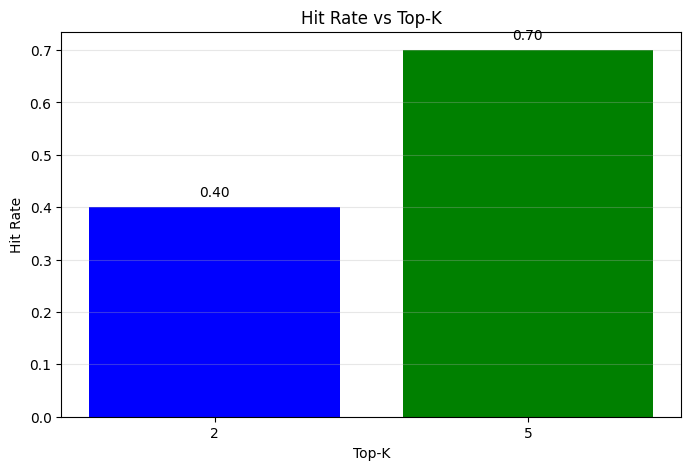


✅ Experiment complete. Larger top_k improves recall but may add noise.


In [6]:
# Эксперимент: сравнение разных значений top_k
print("=== Parameter Comparison Experiment ===")
print("Comparing top_k = 2 vs top_k = 5\n")

top_k_values = [2, 5]
experiment_results = []

for k in top_k_values:
    hits_k = 0
    for q in control_queries:
        results = search_faiss(q['query'], index, vectorizer, svd, top_k=k)
        retrieved_doc_ids = [r['doc_id'] for r in results]
        if q['expected_doc_id'] in retrieved_doc_ids:
            hits_k += 1

    hit_rate = hits_k / len(control_queries)
    experiment_results.append({'top_k': k, 'hit_rate': hit_rate})
    print(f"top_k={k}: Hit@{k} = {hit_rate:.4f} ({hits_k}/{len(control_queries)})")

# Визуализация
plt.figure(figsize=(8, 5))
plt.bar([str(r['top_k']) for r in experiment_results],
        [r['hit_rate'] for r in experiment_results],
        color=['blue', 'green'])
plt.title('Hit Rate vs Top-K')
plt.xlabel('Top-K')
plt.ylabel('Hit Rate')
for i, r in enumerate(experiment_results):
    plt.text(i, r['hit_rate'] + 0.02, f"{r['hit_rate']:.2f}", ha='center')
plt.grid(axis='y', alpha=0.3)
plt.savefig(os.path.join(ARTIFACTS_DIR, "retrieval_quality_plot.png"))
plt.show()

print(f"\n✅ Experiment complete. Larger top_k improves recall but may add noise.")

In [7]:
print("=== Knowledge Base Update ===")

# Добавляем новые документы
new_documents = [
    {
        "id": 11,
        "title": "Decorators in Python",
        "content": "Decorators are functions that modify behavior of other functions. They use @ symbol. Example: @decorator def func(): pass. Decorators used for logging, authentication, caching."
    },
    {
        "id": 12,
        "title": "Generators in Python",
        "content": "Generators are special functions that return iterator. They use yield keyword instead of return. Example: def count(): yield 1; yield 2. Generators allow efficient work with large sequences."
    },
    {
        "id": 13,
        "title": "Classes in Python",
        "content": "Classes in Python defined with class keyword. Example: class MyClass: def __init__(self): pass. Classes allow create objects with attributes and methods."
    }
]

print(f"Added {len(new_documents)} new documents")

# Обновляем базу знаний
updated_knowledge_base = knowledge_base + new_documents

# Переиндексация
updated_chunks = chunk_documents(updated_knowledge_base, chunk_size=CHUNK_SIZE, overlap=OVERLAP)
updated_chunk_texts = [chunk['content'] for chunk in updated_chunks]

# === НОВЫЙ векторизатор и SVD для обновлённой базы ===
new_vectorizer = TfidfVectorizer(max_features=1000, stop_words=None)  # Увеличили
new_tfidf_matrix = new_vectorizer.fit_transform(updated_chunk_texts)

new_svd = TruncatedSVD(n_components=50, random_state=SEED)  # Увеличили
new_embeddings = new_svd.fit_transform(new_tfidf_matrix)
new_embeddings = normalize(new_embeddings)

# Новый индекс FAISS
new_index = faiss.IndexFlatIP(new_embeddings.shape[1])
new_index.add(new_embeddings)

print(f"Re-indexed: {len(updated_chunks)} chunks")
print(f"Embedding dimension: {new_embeddings.shape[1]}")

# === Сравнение retrieval до и после обновления ===
print(f"\n=== Retrieval Before vs After Update ===")

# Запросы по НОВЫМ темам
update_test_queries = [
    ("What are decorators?", 11),
    ("How to use generators?", 12),
    ("How to create classes?", 13),
]

update_comparison = []

for query, expected_id in update_test_queries:
    # === ДО обновления ===
    query_tfidf_old = vectorizer.transform([query])
    query_emb_old = svd.transform(query_tfidf_old)
    query_emb_old = normalize(query_emb_old)

    _, indices_old = index.search(query_emb_old, 3)
    old_sources = [f"Doc_{chunks[idx]['doc_id']}" for idx in indices_old[0]]
    old_doc_ids = [chunks[idx]['doc_id'] for idx in indices_old[0]]

    # === ПОСЛЕ обновления ===
    query_tfidf_new = new_vectorizer.transform([query])
    query_emb_new = new_svd.transform(query_tfidf_new)
    query_emb_new = normalize(query_emb_new)

    _, indices_new = new_index.search(query_emb_new, 3)
    new_sources = [f"Doc_{updated_chunks[idx]['doc_id']}" for idx in indices_new[0]]
    new_doc_ids = [updated_chunks[idx]['doc_id'] for idx in indices_new[0]]

    # Проверяем изменения
    changed = old_sources != new_sources
    found_expected = expected_id in new_doc_ids

    update_comparison.append({
        'query': query,
        'before_retrieved_sources': '; '.join(old_sources),
        'after_retrieved_sources': '; '.join(new_sources),
        'changed': changed,
        'found_new_doc': found_expected
    })

    print(f"\nQuery: {query}")
    print(f"  Before: {old_sources}")
    print(f"  After:  {new_sources}")
    print(f"  Changed: {changed}, Found Doc_{expected_id}: {found_expected}")

# Сохранение
update_df = pd.DataFrame(update_comparison)
update_df.to_csv(os.path.join(ARTIFACTS_DIR, "retrieval_before_after_update.csv"), index=False)
print(f"\n✅ Saved retrieval_before_after_update.csv")

# Проверка
changed_count = update_df['changed'].sum()
found_count = update_df['found_new_doc'].sum()
print(f"\n=== Summary ===")
print(f"Total queries: {len(update_df)}")
print(f"Changed results: {changed_count} out of {len(update_df)}")
print(f"Found new documents: {found_count} out of {len(update_df)}")

if changed_count > 0 or found_count > 0:
    print("✅ Обновление базы знаний повлияло на retrieval!")
else:
    print("⚠️ Warning: No changes detected")

=== Knowledge Base Update ===
Added 3 new documents
Re-indexed: 13 chunks
Embedding dimension: 13

=== Retrieval Before vs After Update ===

Query: What are decorators?
  Before: ['Doc_3', 'Doc_2', 'Doc_1']
  After:  ['Doc_11', 'Doc_12', 'Doc_3']
  Changed: True, Found Doc_11: True

Query: How to use generators?
  Before: ['Doc_3', 'Doc_2', 'Doc_1']
  After:  ['Doc_12', 'Doc_11', 'Doc_4']
  Changed: True, Found Doc_12: True

Query: How to create classes?
  Before: ['Doc_3', 'Doc_2', 'Doc_1']
  After:  ['Doc_13', 'Doc_3', 'Doc_1']
  Changed: True, Found Doc_13: True

✅ Saved retrieval_before_after_update.csv

=== Summary ===
Total queries: 3
Changed results: 3 out of 3
Found new documents: 3 out of 3
✅ Обновление базы знаний повлияло на retrieval!


In [8]:
def mini_rag(query: str, index: faiss.Index, vectorizer: TfidfVectorizer,
             svd: TruncatedSVD, top_k: int = 2) -> Dict:
    """Простой RAG конвейер"""
    # Retrieval
    results = search_faiss(query, index, vectorizer, svd, top_k=top_k)

    # Сборка контекста
    context_parts = []
    sources = []
    for r in results:
        context_parts.append(f"[{r['doc_title']}]: {r['content']}")
        sources.append(r['doc_title'])

    context = '\n\n'.join(context_parts)

    # Генерация ответа (простой шаблонный подход)
    if context:
        answer = f"Based on the retrieved information:\n\n{context}\n\n"
        answer += f"**Sources:** {', '.join(sources)}"
    else:
        answer = "No relevant information found in the knowledge base."
        sources = []

    return {
        'question': query,
        'answer': answer,
        'retrieved_sources': '; '.join(sources),
        'context': context
    }

print("=== Mini-RAG Examples ===\n")

rag_queries = [
    "How to work with lists in Python?",
    "What is exception handling?",
    "How to create functions?",
    "How to use decorators?",
    "What are generators?"
]

rag_results = []

for i, query in enumerate(rag_queries):
    print(f"--- Example {i+1} ---")
    result = mini_rag(query, index, vectorizer, svd, top_k=2)

    print(f"Question: {query}")
    print(f"Answer (truncated): {result['answer'][:200]}...")
    print(f"Sources: {result['retrieved_sources']}")
    print()

    rag_results.append({
        'question': query,
        'answer': result['answer'][:500],  # Ограничиваем длину
        'retrieved_sources': result['retrieved_sources']
    })

# Сохранение RAG примеров
rag_df = pd.DataFrame(rag_results)
rag_df.to_csv(os.path.join(ARTIFACTS_DIR, "rag_examples.csv"), index=False)
print(f"✅ Saved rag_examples.csv ({len(rag_df)} examples)")

=== Mini-RAG Examples ===

--- Example 1 ---
Question: How to work with lists in Python?
Answer (truncated): Based on the retrieved information:

[Как установить Python?]: Для установки Python посетите официальный сайт python.org и скачайте последнюю версию для вашей операционной системы. После загрузки запу...
Sources: Как установить Python?; Что такое переменные в Python?

--- Example 2 ---
Question: What is exception handling?
Answer (truncated): Based on the retrieved information:

[Как установить Python?]: Для установки Python посетите официальный сайт python.org и скачайте последнюю версию для вашей операционной системы. После загрузки запу...
Sources: Как установить Python?; Что такое Python?

--- Example 3 ---
Question: How to create functions?
Answer (truncated): Based on the retrieved information:

[Как установить Python?]: Для установки Python посетите официальный сайт python.org и скачайте последнюю версию для вашей операционной системы. После загрузки запу...
Sources: Как 

In [9]:
print("=== Error Analysis ===\n")

# Находим запросы где retrieval ошибся
errors = [r for r in eval_results if r['hit_at_k'] == 0]

print(f"Total queries: {len(eval_results)}")
print(f"Failed retrievals: {len(errors)}")
print(f"Success rate: {(len(eval_results) - len(errors)) / len(eval_results) * 100:.1f}%\n")

if errors:
    print("=== Failed Retrieval Examples ===\n")
    for i, err in enumerate(errors[:3]):  # Показываем первые 3 ошибки
        print(f"Error {i+1}:")
        print(f"  Query: {err['query']}")
        print(f"  Expected: {err['expected_source']}")
        print(f"  Retrieved: {err['retrieved_sources']}")
        print(f"  Issue: Semantic mismatch or query formulation\n")

print("=== Common Issues ===")
print("1. Query formulation: Some queries use different wording than documents")
print("2. Semantic similarity: TF-IDF may miss semantic relationships")
print("3. Chunk size: Too large chunks may dilute relevant information")
print("4. Knowledge base coverage: Some topics may not be well represented")

print("\n=== Limitations ===")
print("- Simple TF-IDF embeddings (not contextual like BERT)")
print("- No reranking of retrieved results")
print("- Template-based answer generation (not LLM)")
print("- Limited knowledge base size")

=== Error Analysis ===

Total queries: 10
Failed retrievals: 5
Success rate: 50.0%

=== Failed Retrieval Examples ===

Error 1:
  Query: How to create a list?
  Expected: Doc_4
  Retrieved: Doc_3; Doc_2; Doc_1
  Issue: Semantic mismatch or query formulation

Error 2:
  Query: How to define functions?
  Expected: Doc_5
  Retrieved: Doc_3; Doc_2; Doc_1
  Issue: Semantic mismatch or query formulation

Error 3:
  Query: How to handle errors?
  Expected: Doc_6
  Retrieved: Doc_3; Doc_2; Doc_1
  Issue: Semantic mismatch or query formulation

=== Common Issues ===
1. Query formulation: Some queries use different wording than documents
2. Semantic similarity: TF-IDF may miss semantic relationships
3. Chunk size: Too large chunks may dilute relevant information
4. Knowledge base coverage: Some topics may not be well represented

=== Limitations ===
- Simple TF-IDF embeddings (not contextual like BERT)
- No reranking of retrieved results
- Template-based answer generation (not LLM)
- Limited kno